# Bigspin invisible failures technical report

Copyright 2026 Bigspin AI

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

In [1]:
__author__ = "Christopher Potts and Moritz Sudhof"
__date__ = "2026-03-15"

In [2]:
from datasets import load_dataset
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
import pandas as pd
import seaborn as sns

import techreport_utils

In [3]:
plt.style.use("bigspin.mplstyle")

In [4]:
FIGURE_OUTPUT_DIRNAME = "fig"

In [5]:
DATA_DIRNAME = "data"

## Raw WildChat

In [6]:
wildchat = load_dataset("allenai/WildChat-1M")

In [7]:
def count_wildchat_en():    
    lang = wildchat['train']['language']
    count = 0
    for i in range(len(lang)):
        count += (lang[i] == "English")
    return count

In [8]:
# count_wildchat_en() # 478498

## Main dataset

In [9]:
full_df = pd.read_json(
    os.path.join(DATA_DIRNAME, "wildchat_bigspin_annotations_v1.json.gz"))

In [10]:
full_df['signals'] = full_df.signals_json.apply(techreport_utils.get_signals)

In [11]:
full_df['archetypes'] = full_df.signals.apply(techreport_utils.assign_archetypes)

In [12]:
full_df["invalid_input"] = full_df.signals.apply(lambda x: "invalid_input" in x)

In [13]:
df = full_df[full_df.invalid_input == False].copy()

In [14]:
full_df.shape

(196704, 22)

In [15]:
# Number of cases we're going to use for the main analyses:

df.shape[0]

168563

In [16]:
# Number of "invalid_input" cases:

full_df.shape[0] - df.shape[0]

28141

## Overall quality distribution

In [17]:
canonical_quality_label_ordering = ['critical', 'poor', 'acceptable', 'good']

In [18]:
quality_dist = df.overall_quality.value_counts()

In [19]:
quality_dist_per = quality_dist / quality_dist.sum()

In [20]:
# Percentage of transcripts below "good":

(quality_dist_per.drop("good").sum() * 100).round(0)

np.float64(37.0)

In [21]:
# Percentage good/acceptable:

(quality_dist_per[['good', 'acceptable']].sum() * 100).round(0)

np.float64(84.0)

In [102]:
def quality_dist_plot(df, output_filename="overall_quality.pdf"):
    dist = df.overall_quality.value_counts()
    total = dist.sum()
    ax = dist[canonical_quality_label_ordering].plot.barh(
        figsize=(6, 3), color="#D95F02")
    for patch in ax.patches:
        count = int(patch.get_width())
        pct = count / total * 100
        y_center = patch.get_y() + patch.get_height() / 2
        x_pos = patch.get_width()
        ax.text(x_pos + 1, y_center, f"{count:,} ({pct:.1f}%)", va="center")    
    ax.set_ylabel("")
    ax.set_xlabel("Number of transcripts")
    ax.set_xlim([0, 110_000])    
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

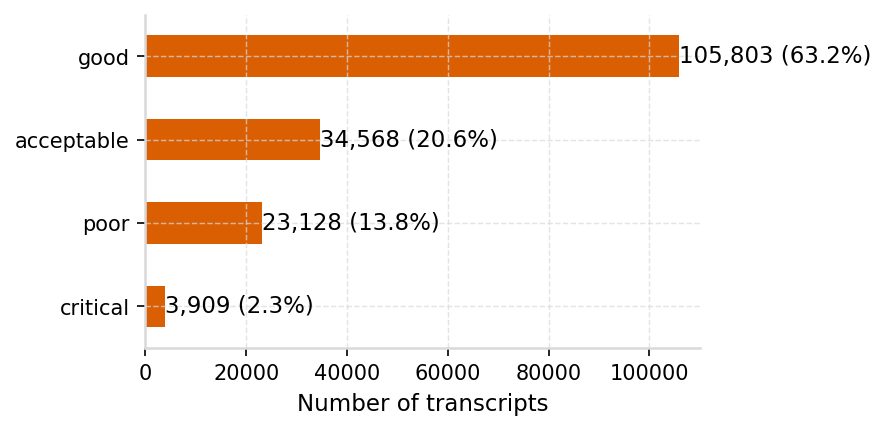

In [103]:
quality_dist_plot(df)

In [105]:
# Number of examples with missing overall quality tags:

full_qual_dist = df.overall_quality.value_counts(dropna=False)

In [109]:
full_qual_dist[None]

np.int64(1155)

## Signal tags

In [24]:
all_attested_signals = {x for vals in df.signals for x in vals}

In [25]:
len(all_attested_signals)

28

In [26]:
all_attested_signals

{'ai_error_factual',
 'ai_explicit_refusal',
 'ai_false_confidence',
 'ai_implicit_refusal',
 'ai_incomplete_response',
 'ai_malfunction',
 'ai_misunderstanding',
 'ai_off_topic_drift',
 'ai_poor_response_quality',
 'ai_self_contradiction',
 'ai_self_correction',
 'ambiguous_request',
 'ethical_tension',
 'explicit_user_correction',
 'explicit_user_dissatisfaction',
 'goal_failure',
 'implicit_user_correction',
 'implicit_user_dissatisfaction',
 'partial_success',
 'recovery',
 'repetition',
 'task_success',
 'user_abandonment',
 'user_clarification',
 'user_frustration',
 'user_passive_acceptance',
 'user_scope_change',
 'user_validation_seeking'}

In [27]:
def signals_dist_plot(df, output_filename="signals.pdf"):
    sigs = pd.Series([x for vals in df.signals for x in vals])
    dist = sigs.value_counts()
    ax = dist.sort_values(ascending=True).plot.barh(
        figsize=(8, 7), color='#5CAD70')  
    total = df.shape[0] # Total transcripts
    for patch in ax.patches:
        count = int(patch.get_width())
        pct = count / total * 100
        y_center = patch.get_y() + patch.get_height() / 2  
        x_pos = patch.get_width()
        if pct > 0.02:
            pct_str = f"{pct:.1f}%"
        else:
            pct_str = "< 0.01%"
        ax.text(x_pos + 1, y_center, f"{count:,}; {pct_str}", va="center", fontsize=8)
    ax.set_ylabel("")
    ax.set_xlabel("Signal frequency")    
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

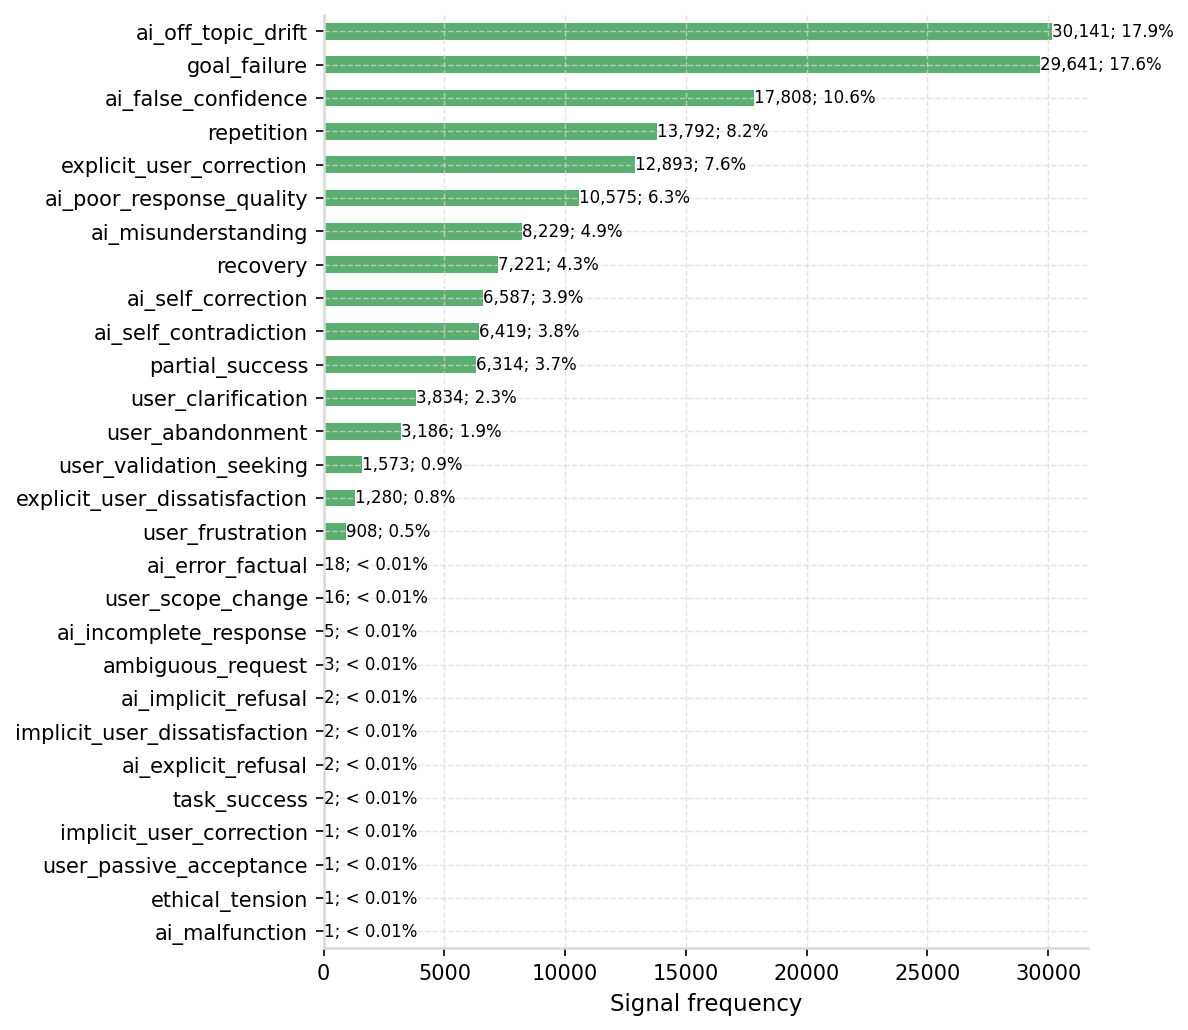

In [28]:
signals_dist_plot(df)

In [29]:
def goal_failure_count(df):
    sigs = pd.Series([x for vals in df.signals for x in vals])
    dist = sigs.value_counts()
    return dist['goal_failure']

In [30]:
# Just double-checking this against the plot:

goal_failure_count(df)

np.int64(29641)

## Signal counts per category

In [31]:
def signals_per_category(df, cat):
    d = df[df.overall_quality == cat].signal_count.value_counts()
    d = d / d.sum()
    return d

In [32]:
# Percentage "poor" with at least 2 signals:

d = signals_per_category(df, "poor")
(d[d.index >=2].sum() * 100).round(1)

np.float64(92.4)

In [33]:
# Percentage "critical" with at least 2 signals:

cd = signals_per_category(df, "critical")
(cd[cd.index >=2].sum() * 100).round(1)

np.float64(86.6)

## Signal categories per quality category

In [34]:
def signals_barplot(df, cat, ax=None):
    cat_df = df[df.overall_quality == cat]
    sigs = pd.Series([x for vals in cat_df.signals for x in vals])
    dist = sigs.value_counts()
    dist = dist.iloc[: 10]
    ax = dist.sort_values(ascending=True).plot.barh(ax=ax, color='#5CAD70')    
    ax.bar_label(ax.containers[0], fmt="{:,.0f}", label_type='edge', fontsize=6)
    ax.set_title(cat)
    ax.set_xlabel("Signal frequency")
    ax.set_xlim([0, 22000])
    return ax

In [35]:
def signals_barplot_all_categories(df, output_filename="top_signals.pdf"):
    fig, axes = plt.subplots(2, 2, figsize=(9, 5))
    signals_barplot(df, "good", ax=axes[0][0])
    signals_barplot(df, "acceptable", ax=axes[0][1])
    signals_barplot(df, "poor", ax=axes[1][0])
    signals_barplot(df, "critical", ax=axes[1][1])
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

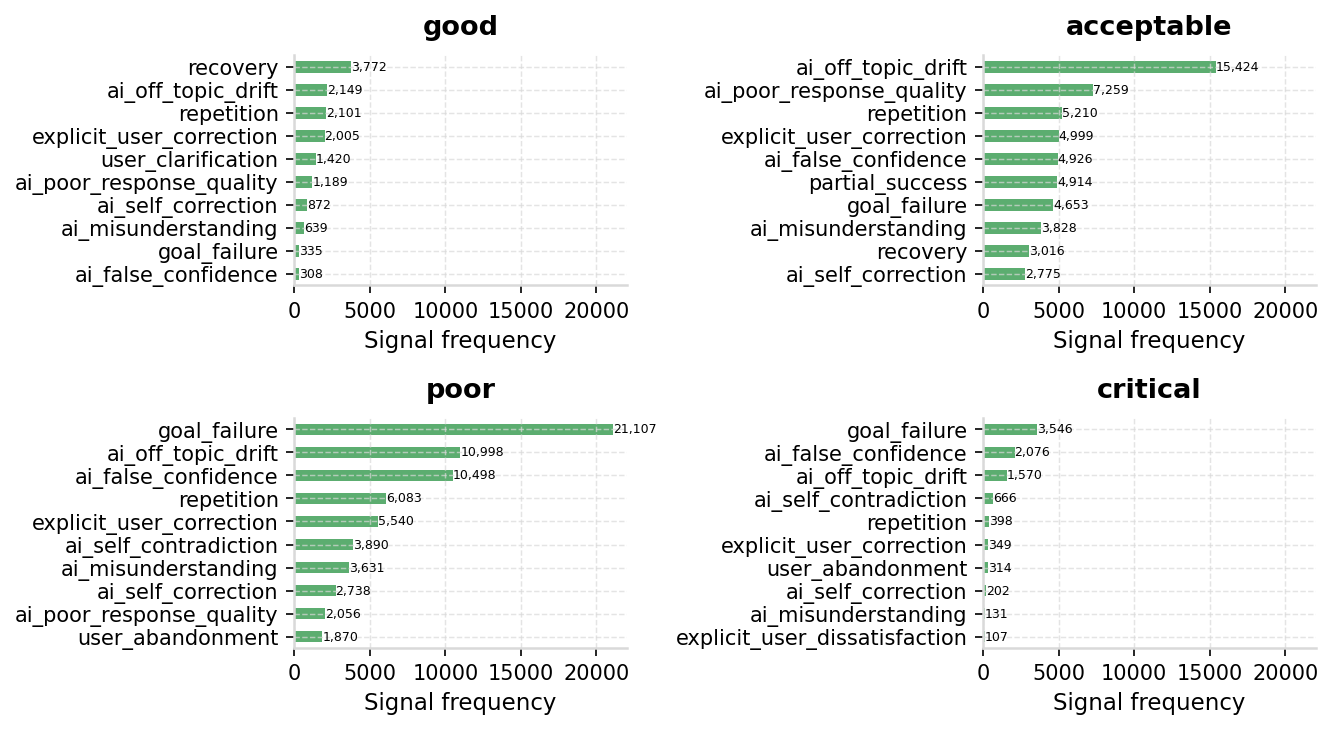

In [36]:
signals_barplot_all_categories(df)

## Signal density and quality

In [37]:
def signal_density_plot(df, output_filename="quality_by_signals.pdf"):
    fig, ax = plt.subplots(figsize=(9, 3))
    df['signal_count_log'] = np.log(df.signal_count)
    sns.violinplot(
        data=df, 
        x="overall_quality", 
        y=np.log1p(df["signal_count"]),
        color="#E7298A", ax=ax)    
    ax.set_xlabel("")
    ax.set_ylabel("Signal count per transcript")
    ax.tick_params(axis="x", rotation=0)          
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(np.expm1(x))}"))
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

/opt/anaconda3/envs/bigspin/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


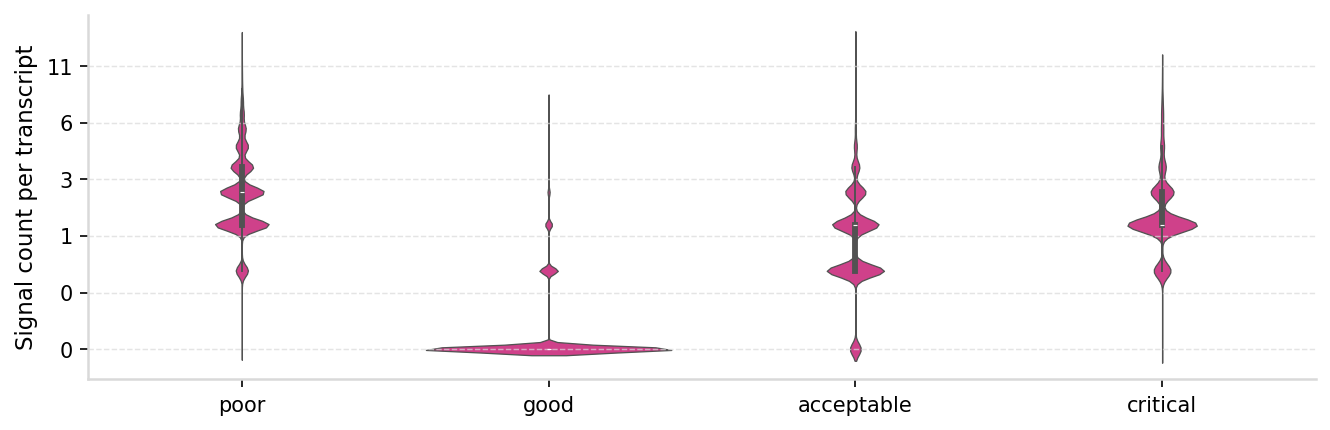

In [38]:
signal_density_plot(df)

In [39]:
qs = df.groupby("overall_quality").signal_count.value_counts().sort_index()

In [40]:
for cat in canonical_quality_label_ordering:
    per = qs[cat] / qs[cat].sum()  
    pct = per[0.0] * 100
    print(f"{cat} percentage with 0 quality labels: {pct:.2f}%")

critical percentage with 0 quality labels: 0.03%
poor percentage with 0 quality labels: 0.00%
acceptable percentage with 0 quality labels: 7.38%
good percentage with 0 quality labels: 90.04%


In [41]:
qs_critical = qs['critical']
(qs_critical[qs_critical.index >= 2].sum() / qs_critical.sum() * 100).round(1)

np.float64(86.6)

In [42]:
qs_acceptable = qs['acceptable']
(qs_acceptable[qs_acceptable.index != 0.0].sum() / qs_acceptable.sum() * 100).round(1)

np.float64(92.6)

## Domains

In [43]:
full_df.primary_vertical.value_counts().shape

(59,)

In [44]:
full_df.secondary_vertical.value_counts().shape

(104,)

In [45]:
def primary_domain_plot(df, output_filename="primary_vertical.pdf"):
    dist = df.primary_vertical.value_counts()
    ax = dist.sort_values(ascending=True).plot.barh(figsize=(8, 15), logx=False, color="#666666")
    ax.bar_label(ax.containers[0], fmt="{:,.0f}", label_type='edge', fontsize=6)
    ax.set_ylabel("")
    ax.set_xlabel("Transcripts")
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

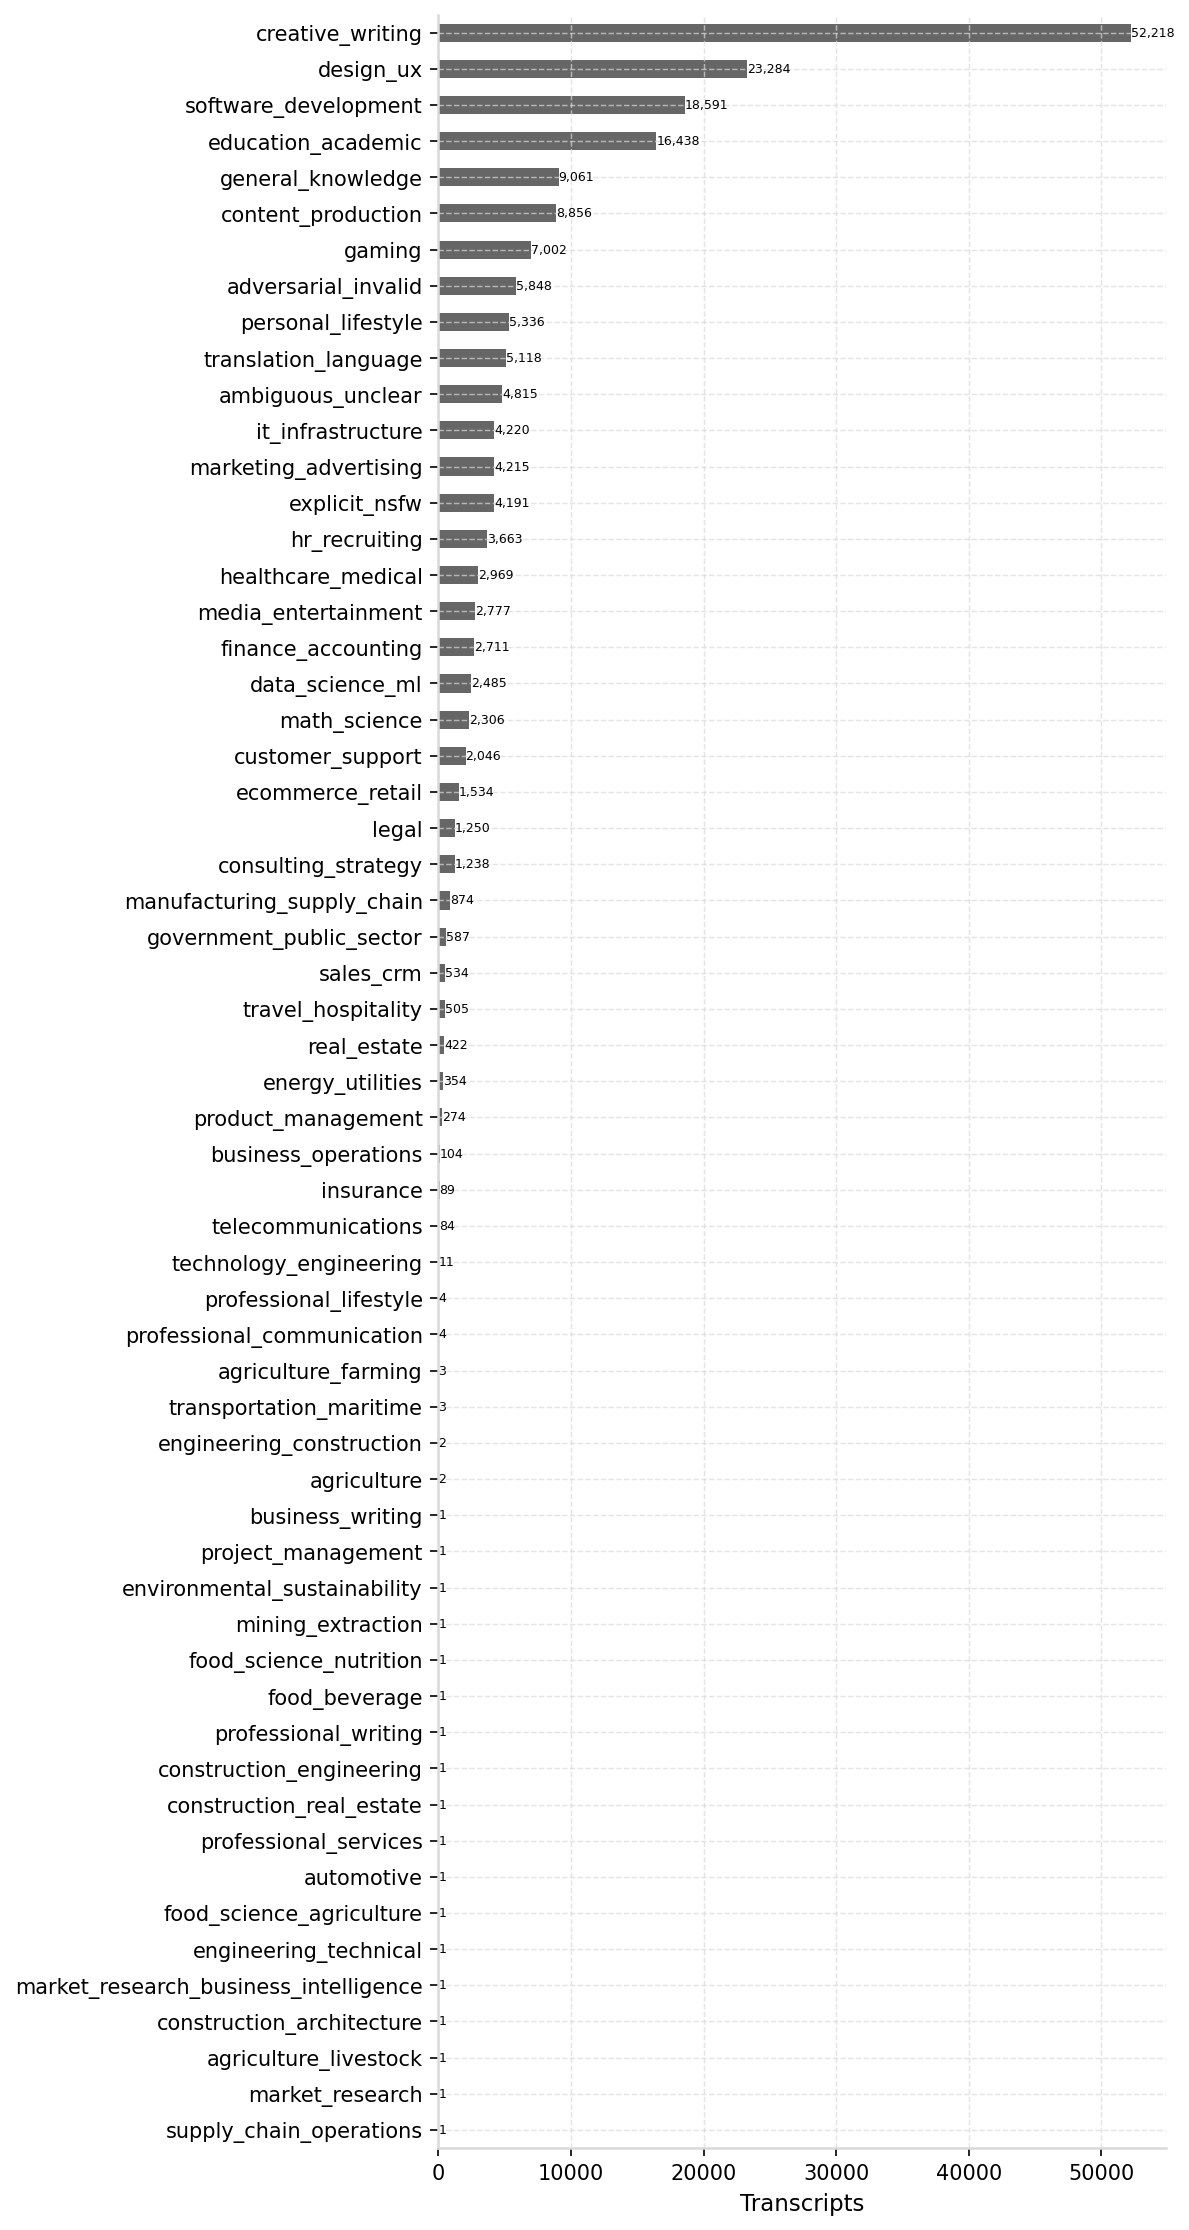

In [46]:
primary_domain_plot(full_df)

## Turn distribution

In [47]:
def turn_dist_plot(df, output_filename="turns.pdf"):
    dist = df.turns.value_counts()
    ax = dist.plot.bar(logy=False, figsize=(12, 5), color="#E6AB02")

    total = dist.sum()

    for patch in ax.patches:
        count = int(patch.get_height())
        pct = count / total * 100
        x_center = patch.get_x() + patch.get_width() / 10
        x_pos = patch.get_height()
        if pct > 2:
            ax.text(x_center, x_pos + 1000, f"{count:,}; {pct:.1f}%", va="bottom", fontsize=8, rotation=90)
        else:
            ax.text(x_center, x_pos + 1000, f"{count:,}", va="bottom", fontsize=8, rotation=90)
    ax.tick_params(axis='x', labelrotation=0, labelsize=8)
    ax.set_xlabel("User turns")
    ax.set_ylabel("Transcripts")
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

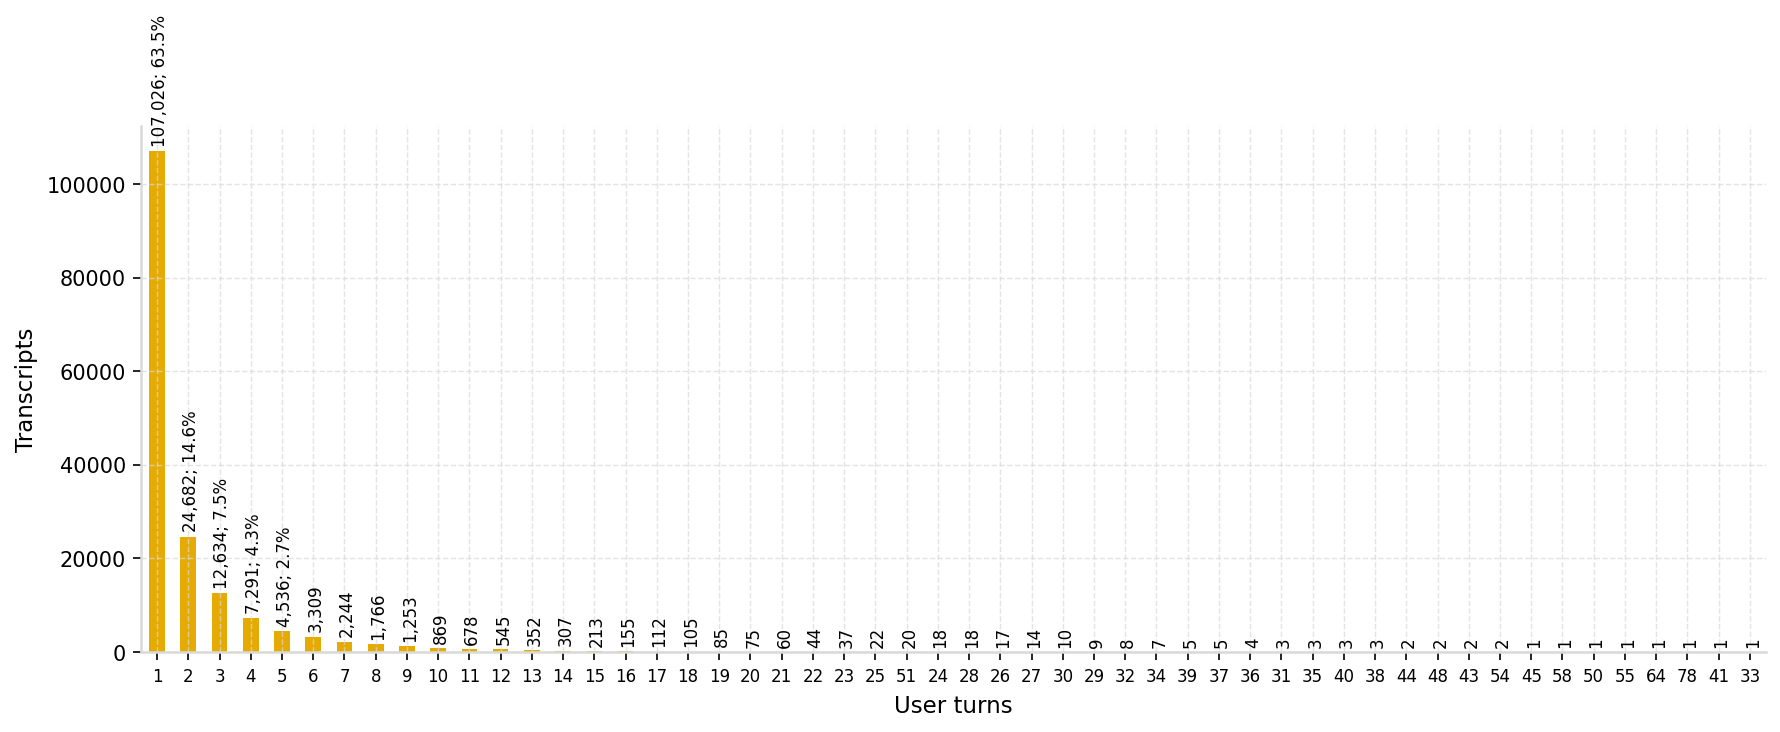

In [48]:
turn_dist_plot(df)

## Archetype distribution

In [49]:
print(",\n".join([r"\signal{" + s + "}" for s in sorted(techreport_utils.visible_signals)]))

\signal{ai_explicit_refusal},
\signal{ai_malfunction},
\signal{explicit_user_correction},
\signal{explicit_user_dissatisfaction},
\signal{user_clarification},
\signal{user_frustration},
\signal{user_scope_change},
\signal{user_validation_seeking}


In [50]:
for x in techreport_utils.visible_signals:
    assert x in techreport_utils.signal_mapping.values(), f"`{x}` not in signal set"

In [51]:
fail_df = df[df.signals.apply(lambda x: 'goal_failure' in x)]

In [52]:
fail_df.shape

(29640, 23)

In [53]:
archs = pd.Series([x for vals in fail_df.archetypes for x in vals])
canonical_archetype_ordering = list(archs.value_counts().index[::-1])

canonical_archetype_ordering

['The walkaway',
 'The partial recovery',
 'The death spiral',
 'The contradiction unravel',
 'The silent mismatch',
 'The mystery failure',
 'Visible failure',
 'The confidence trap',
 'The drift']

In [54]:
# Percentage of failure cases overall:

round(((fail_df.shape[0] / df.shape[0]) * 100), 0)

18.0

In [55]:
# Percentage of failures that are silent:

vis_invis_counts = fail_df.archetypes.apply(lambda x: "visible" if x == ["Visible failure"] else "invisible").value_counts()

vis_invis_counts

archetypes
invisible    23058
visible       6582
Name: count, dtype: int64

In [56]:
(vis_invis_counts / vis_invis_counts.sum()).round(2)

archetypes
invisible    0.78
visible      0.22
Name: count, dtype: float64

In [57]:
def archetype_dist_plot(df, output_filename="archetypes.pdf"):
    archs = pd.Series([x for vals in df.archetypes for x in vals])
    dist = archs.value_counts()        
    ax = dist[canonical_archetype_ordering].plot.barh(figsize=(8, 4))
    total = df.shape[0] # Total transcripts
    for patch in ax.patches:
        count = int(patch.get_width())
        pct = count / total * 100
        y_center = patch.get_y() + patch.get_height() / 2  
        x_pos = patch.get_width()
        if pct > 0.051:
            ax.text(x_pos + 1, y_center, f"{count:,}; {pct:.1f}%", va="center", fontsize=8)
        else:
            ax.text(x_pos + 1, y_center, f"{count:,}; < 0.05%", va="center", fontsize=8)
    ax.set_ylabel("")
    ax.set_xlabel("Archetype frequency")
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

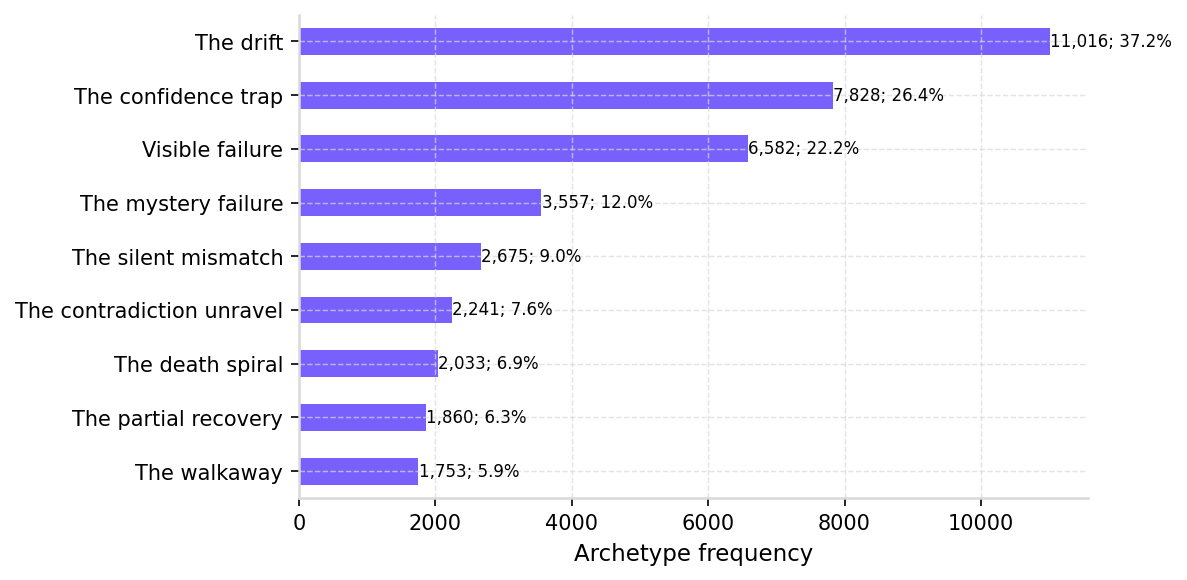

In [58]:
archetype_dist_plot(fail_df)

## Multiturn archetype distribution

In [59]:
multi_df = fail_df[fail_df.turns > 1]

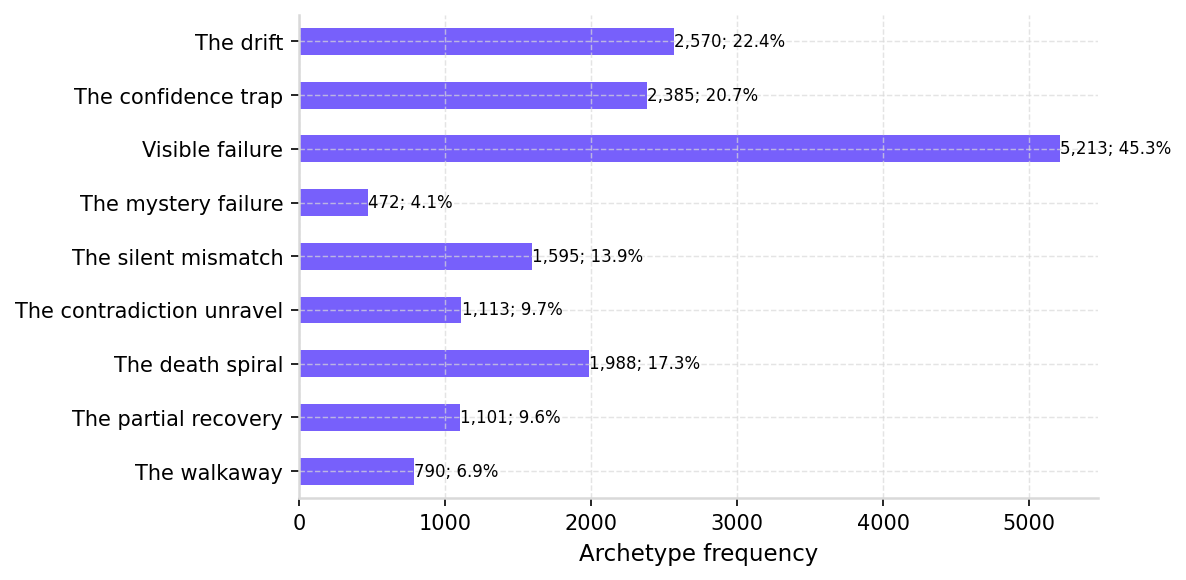

In [60]:
archetype_dist_plot(
    multi_df, 
    output_filename="archetypes_multiturn.pdf")

In [61]:
# Percentage invisible for multiturn cases:

multi_invis = multi_df[multi_df.archetypes.apply(lambda x: x != ["Visible failure"])] 

multi_invis.shape[0] / multi_df.shape[0]

0.5465379262352122

## Archetypes and quality

In [97]:
poor_or_critical = fail_df[fail_df.overall_quality.apply(
    lambda x: x in {"poor", "critical"})]

In [100]:
poor_or_critical_vis_dist = poor_or_critical.archetypes.apply(
    lambda x: "visible" if x == ["Visible failure"] else "invisible"
).value_counts()

In [101]:
# Percentage poor or critical manifesting at least one 
# invisible failure archetype:

(poor_or_critical_vis_dist / poor_or_critical_vis_dist.sum() * 100).round(0)

archetypes
invisible    76.0
visible      24.0
Name: count, dtype: float64

In [65]:
def archetype_quality_xtab(df):
    data = []
    for _, row in df.iterrows():
        for a in row.archetypes:
            data.append({
                'overall_quality': row['overall_quality'], 
                'archetype': a
            })
    data = pd.DataFrame(data)
    xtab = pd.crosstab(data.archetype, data.overall_quality)
    return xtab

In [66]:
aq_xtab = archetype_quality_xtab(fail_df)

In [67]:
def archetype_quality_plot(xtab, output_filename="archetype_quality.pdf"):
    xtab = xtab.loc[canonical_archetype_ordering, canonical_quality_label_ordering]
    dist = (xtab.T / xtab.sum(axis=1)).T
    ax = dist.plot.barh(figsize=(10, 9), legend='reverse', width=0.7)
    for c in ax.containers:
        ax.bar_label(c, fmt="{:.02f}", label_type='edge', fontsize=8)
    ax.set_xlabel("P(overall_quality | archetype)")
    ax.set_ylabel("")
    ax.set_xlim([0, 1.0])
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

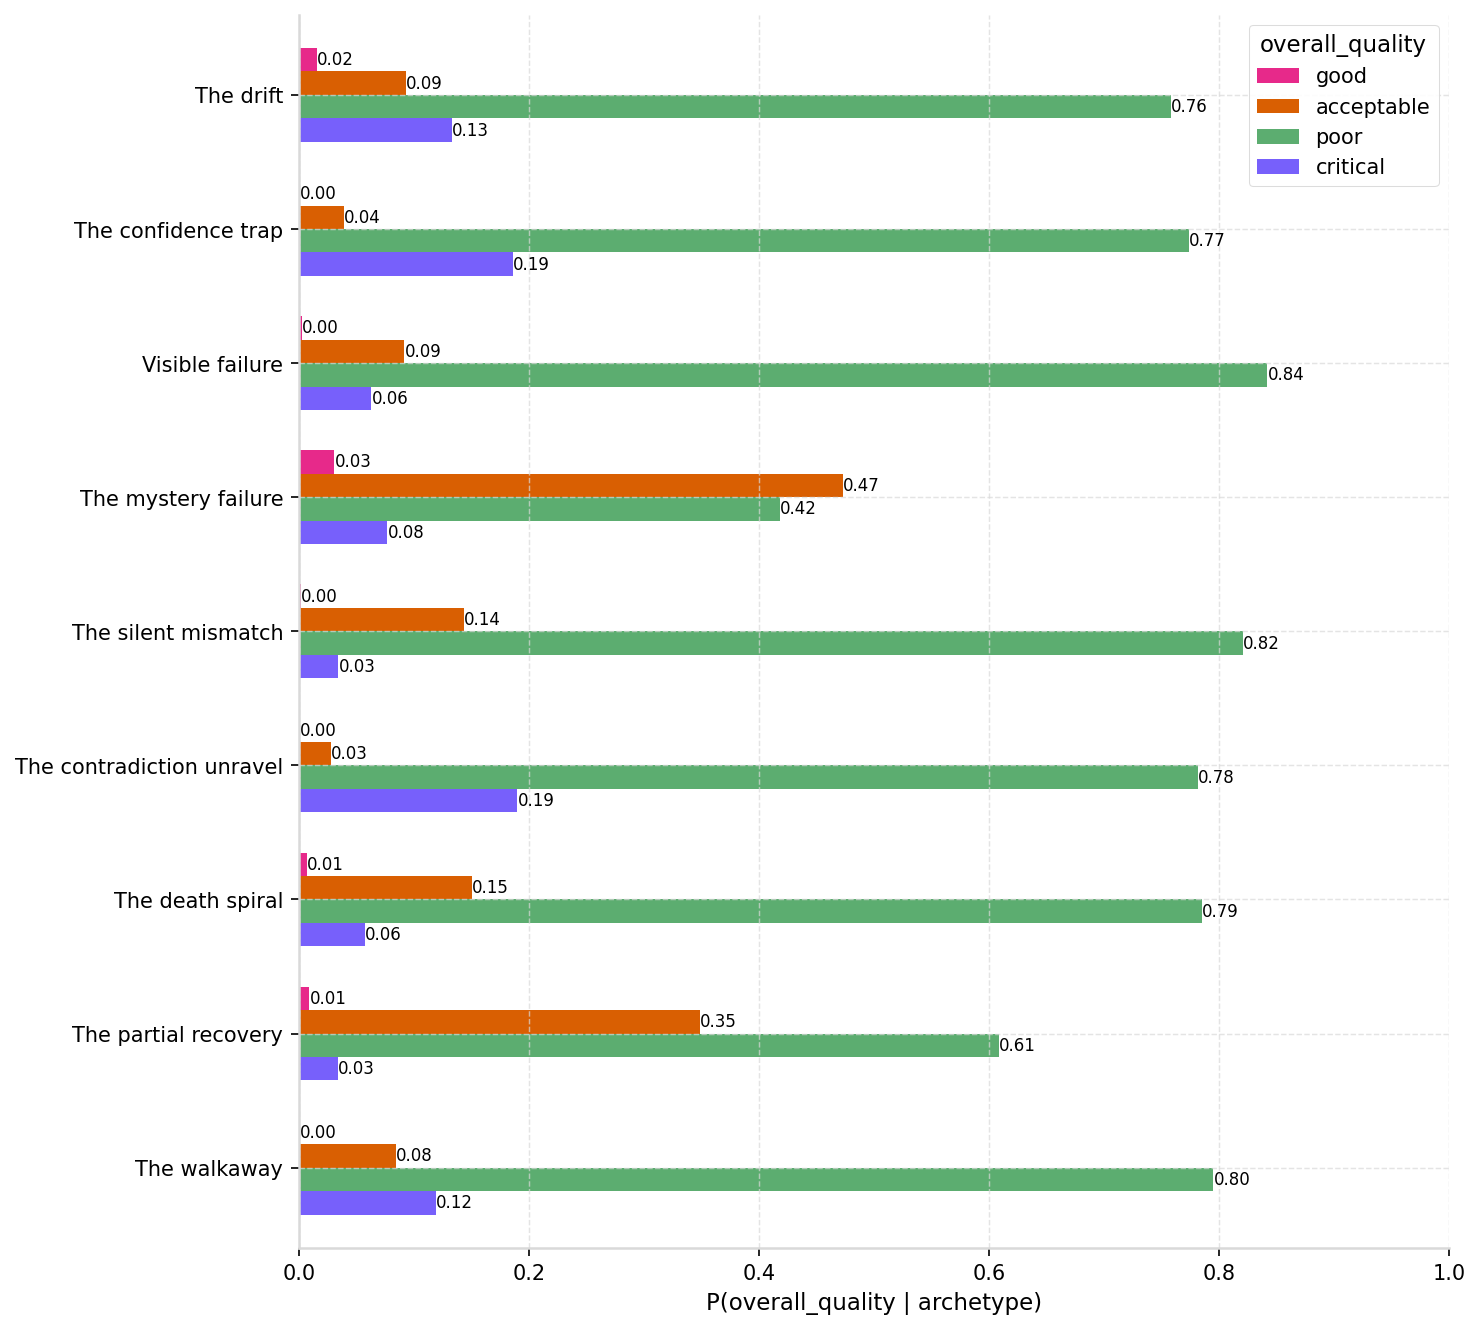

In [68]:
archetype_quality_plot(aq_xtab)

## Archetype co-occurrence

In [69]:
def archetype_xtab(df):
    data = []
    for archs in df.archetypes:
        for i in range(len(archs)):
            for j in range(len(archs)):
                if i != j:
                    data.append({"archetype1": archs[i], "archetype2": archs[j]})
    return pd.DataFrame(data)

In [70]:
arch_cooccur_df = archetype_xtab(fail_df)

In [71]:
def archetype_cooccur_plot(df, output_filename="archetype_cooccur.pdf"):
    heatmap_data = (
        df.groupby(["archetype1", "archetype2"])
        .size()
        .unstack(fill_value=0))
    heatmap_data = techreport_utils.pmi(heatmap_data, positive=True)
    canon = [d for d in canonical_archetype_ordering if d in heatmap_data.columns]
    heatmap_data = heatmap_data.loc[canon, canon]
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(
        heatmap_data, 
        cmap="Purples",
        linewidths=0.5, 
        ax=ax,
        annot=True, 
        fmt=".2f",
        cbar_kws={"label": "PPMI"})
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

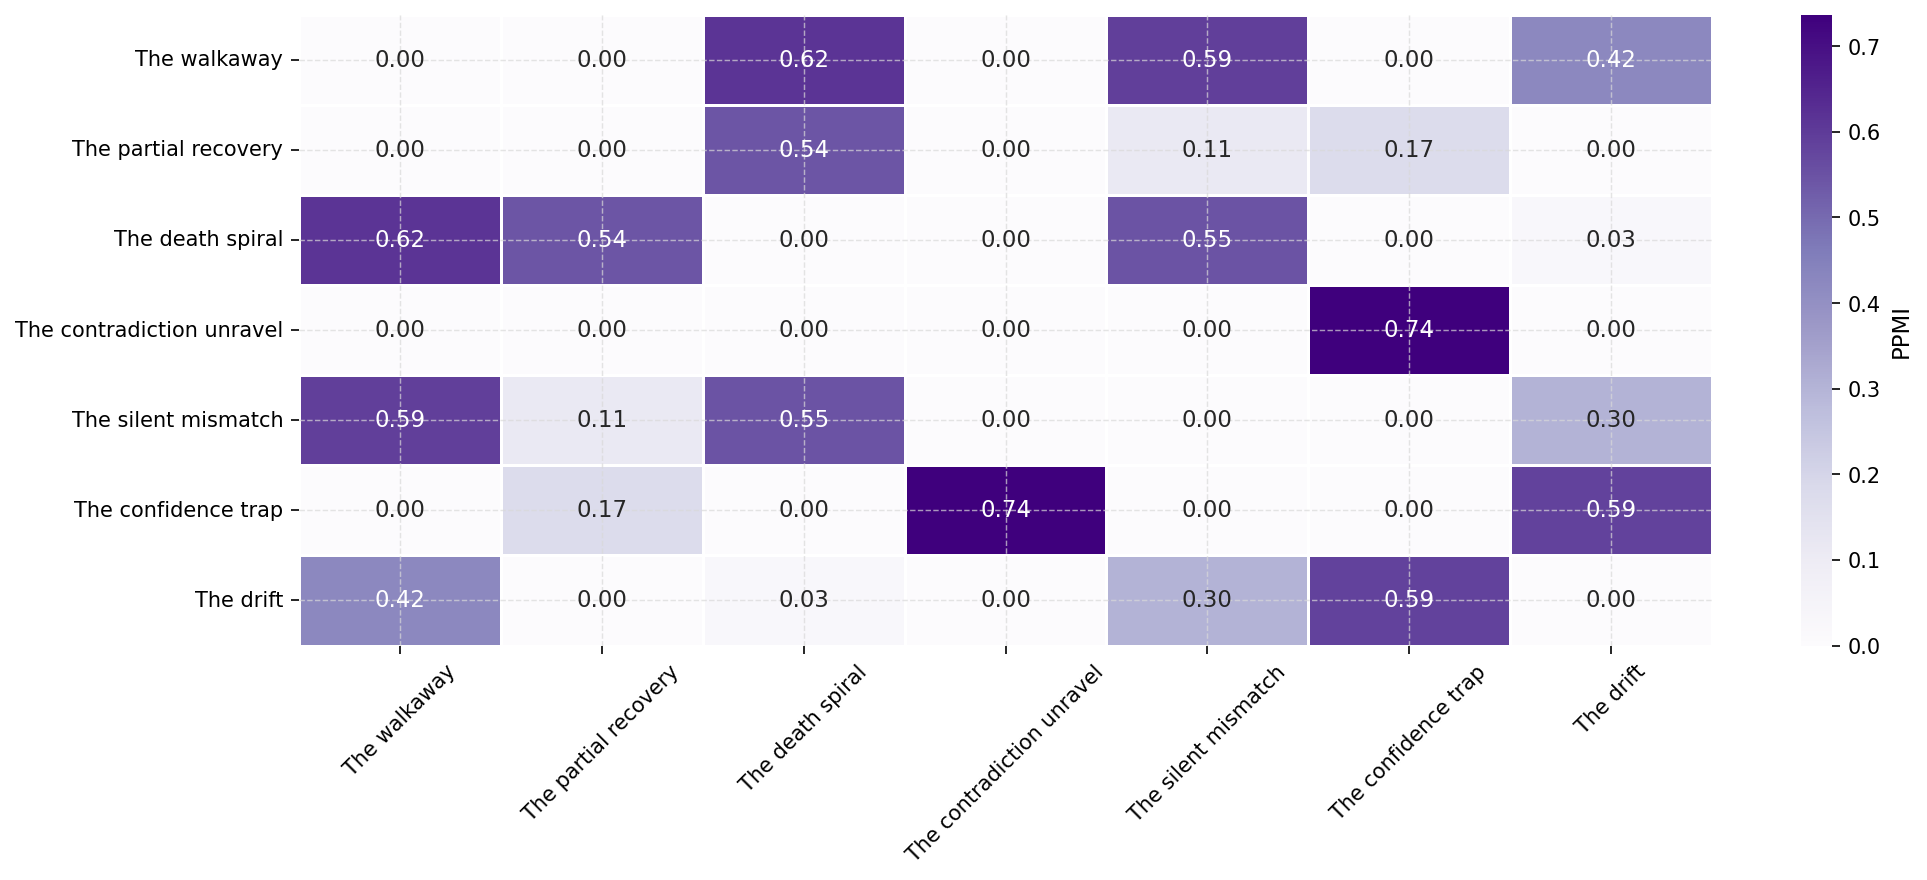

In [72]:
archetype_cooccur_plot(arch_cooccur_df)

## Domains and archetypes

In [73]:
most_frequent_domains = df.primary_vertical.value_counts().iloc[: 10].index.tolist()

In [74]:
most_frequent_domains

['creative_writing',
 'design_ux',
 'software_development',
 'education_academic',
 'general_knowledge',
 'content_production',
 'personal_lifestyle',
 'translation_language',
 'gaming',
 'it_infrastructure']

In [75]:
def domain_archetype_xtab(df):
    data = []
    for _, row in df.iterrows():
        for a in row.archetypes:
            data.append({
                'primary_vertical': row['primary_vertical'], 
                'archetype': a
            })  
    data = pd.DataFrame(data)
    xtab = pd.crosstab(data.primary_vertical, data.archetype)
    return xtab

In [76]:
da_xtab = domain_archetype_xtab(fail_df)

In [77]:
da_prob = (da_xtab.T / da_xtab.sum(axis=1)).T

In [78]:
da_pmi = techreport_utils.pmi(da_xtab, positive=True)

In [79]:
def domain_archetype_plot(X, typ="ppmi"):
    heatmap_data = X.loc[
        most_frequent_domains, 
        canonical_archetype_ordering[::-1]
    ]
    if typ == "ppmi":
        ylabel = "PPMI"
    elif typ == "prob":
        ylabel = "P(archetype | domain)"
    elif typ == "count":
        ylabel = "Co-occurrences"
    else:
        raise ValueError(f"typ value {typ} not recognised")        
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(heatmap_data, cmap="Blues", annot=True,
                fmt=".2f",
                linewidths=0.5, ax=ax,
                cbar_kws={"label": ylabel})
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    output_filename = f"archetype_domain_{typ}.pdf"
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

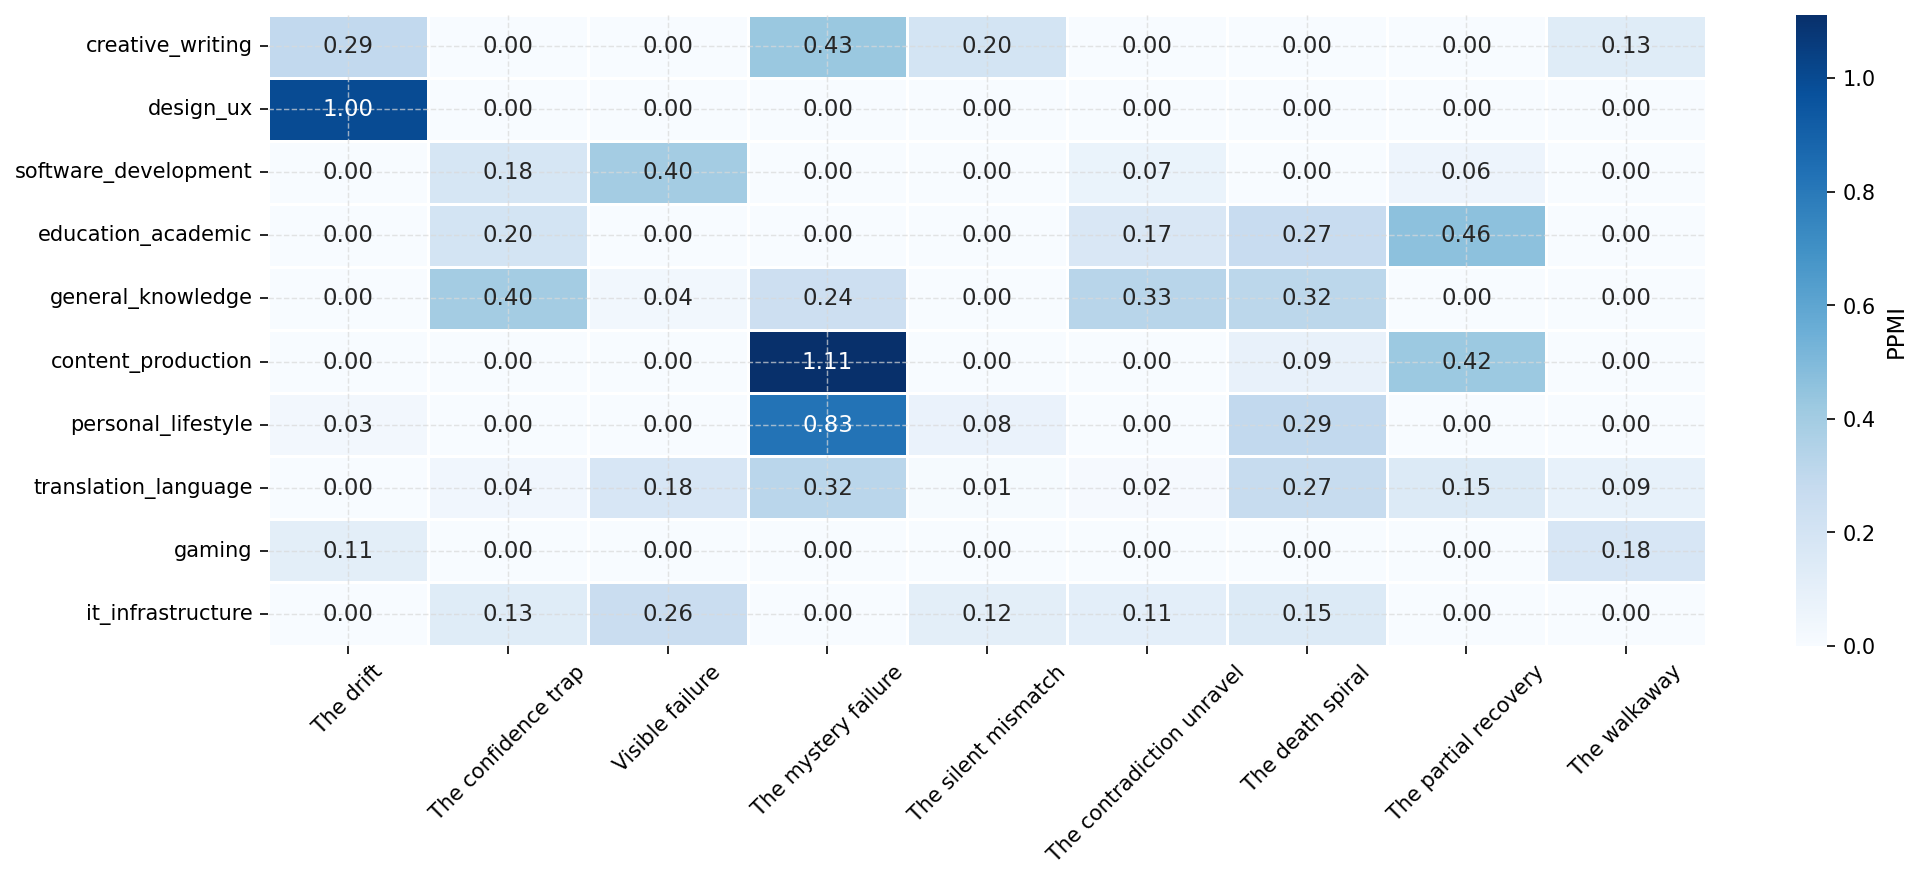

In [80]:
domain_archetype_plot(da_pmi)

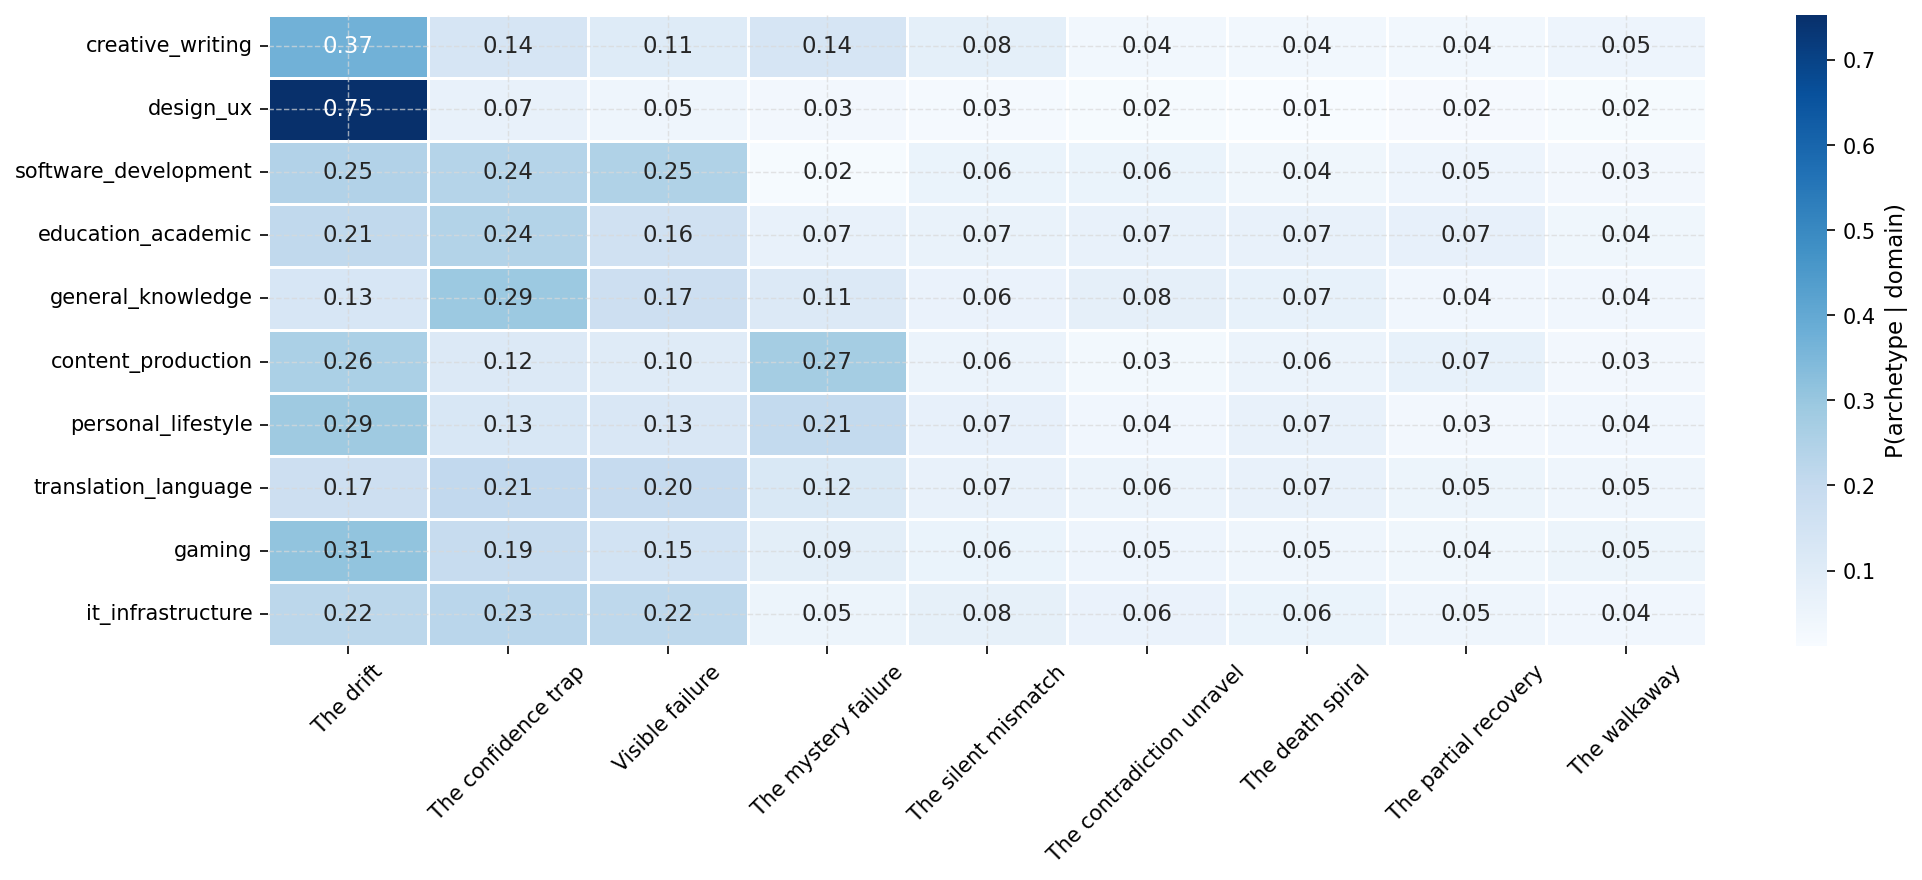

In [81]:
domain_archetype_plot(da_prob, "prob")

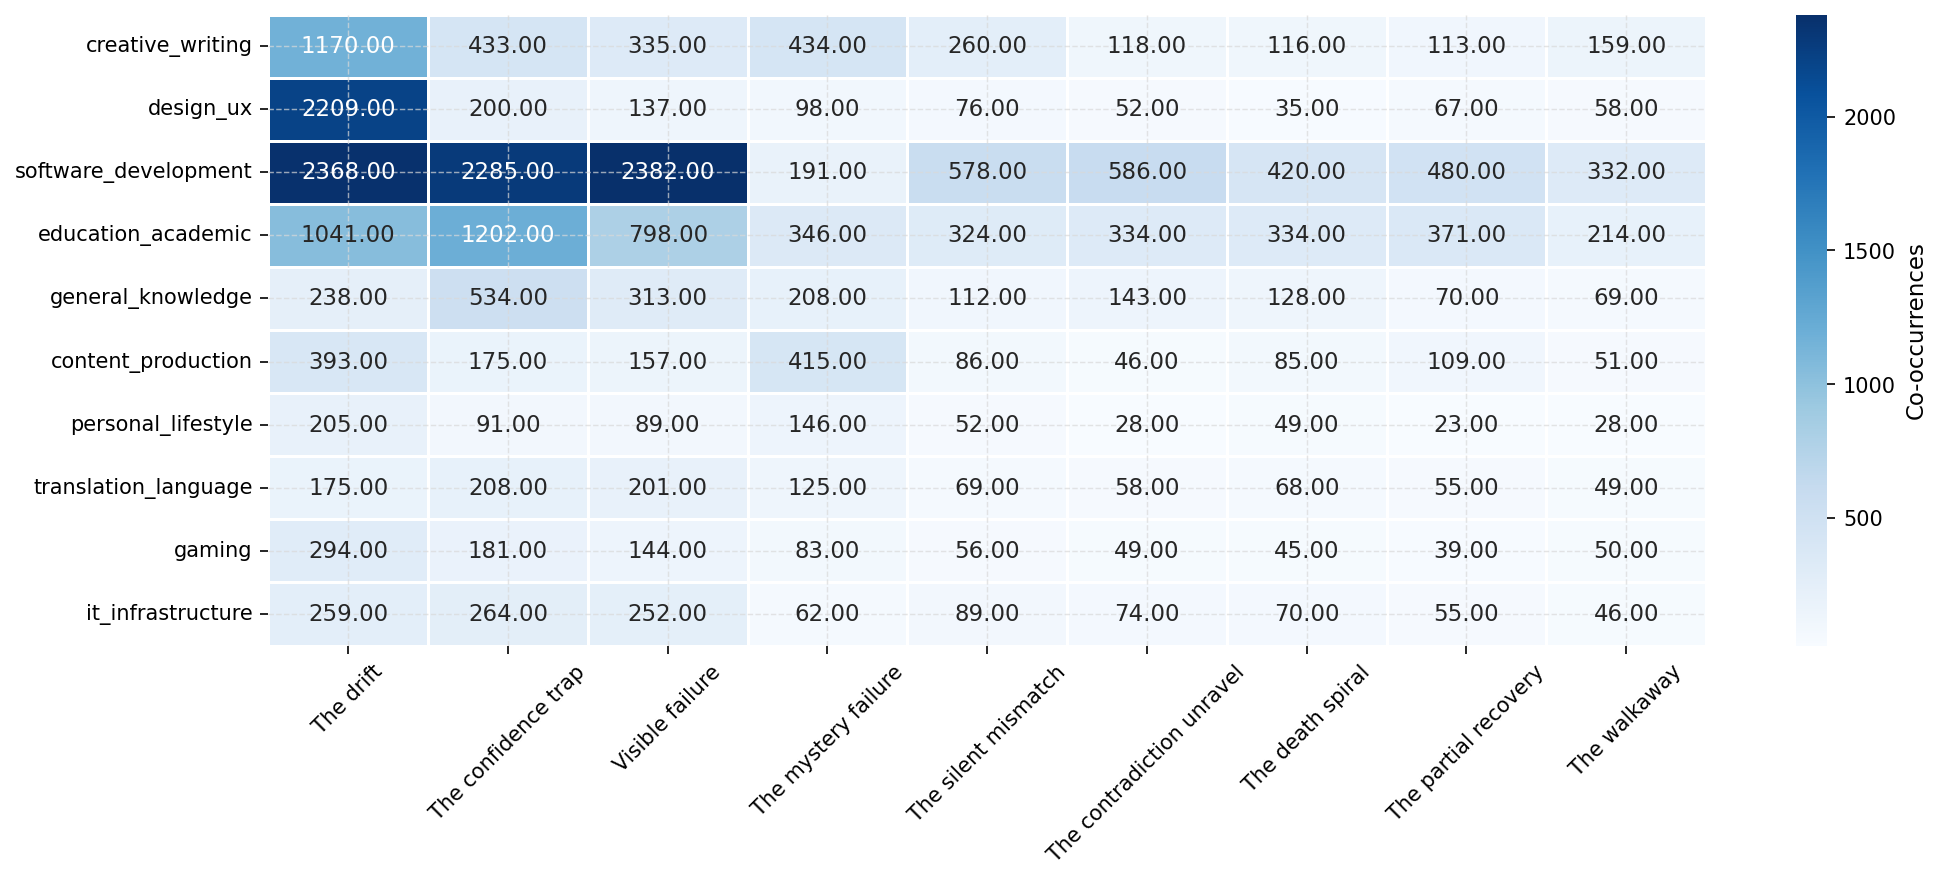

In [82]:
domain_archetype_plot(da_xtab, "count")

## Invalid input examples

In [83]:
def invalid_by_domain_plot(df, output_filename="invalid_domains.pdf"):
    dist = df.primary_vertical.value_counts()
    canon = dist.sort_values(ascending=True).index
    dist = df.groupby("primary_vertical")['invalid_input'].apply(lambda x: x.mean() * 100)
    dist = dist[canon]
    count_dist = df.groupby("primary_vertical")['invalid_input'].sum()    
    total_dist = df.groupby("primary_vertical")['invalid_input'].apply(lambda x: x.shape[0])    
    ax = dist.plot.barh(figsize=(8, 15), logx=False, color="#666666")
    for patch, dom in zip(ax.patches, canon):
        mu = int(patch.get_width())
        pct = mu 
        total = total_dist[dom]
        count = count_dist[dom]
        y_center = patch.get_y() + patch.get_height() / 2  
        x_pos = patch.get_width()
        ax.text(x_pos + 1, y_center, f"{count} / {total} = {pct:.1f}%", va="center", fontsize=8)
    ax.set_ylabel("")
    ax.set_xlabel("Percentage invalid")
    plt.tight_layout()
    output_filename = os.path.join(FIGURE_OUTPUT_DIRNAME, output_filename)
    plt.savefig(output_filename)
    plt.show()
    plt.close()

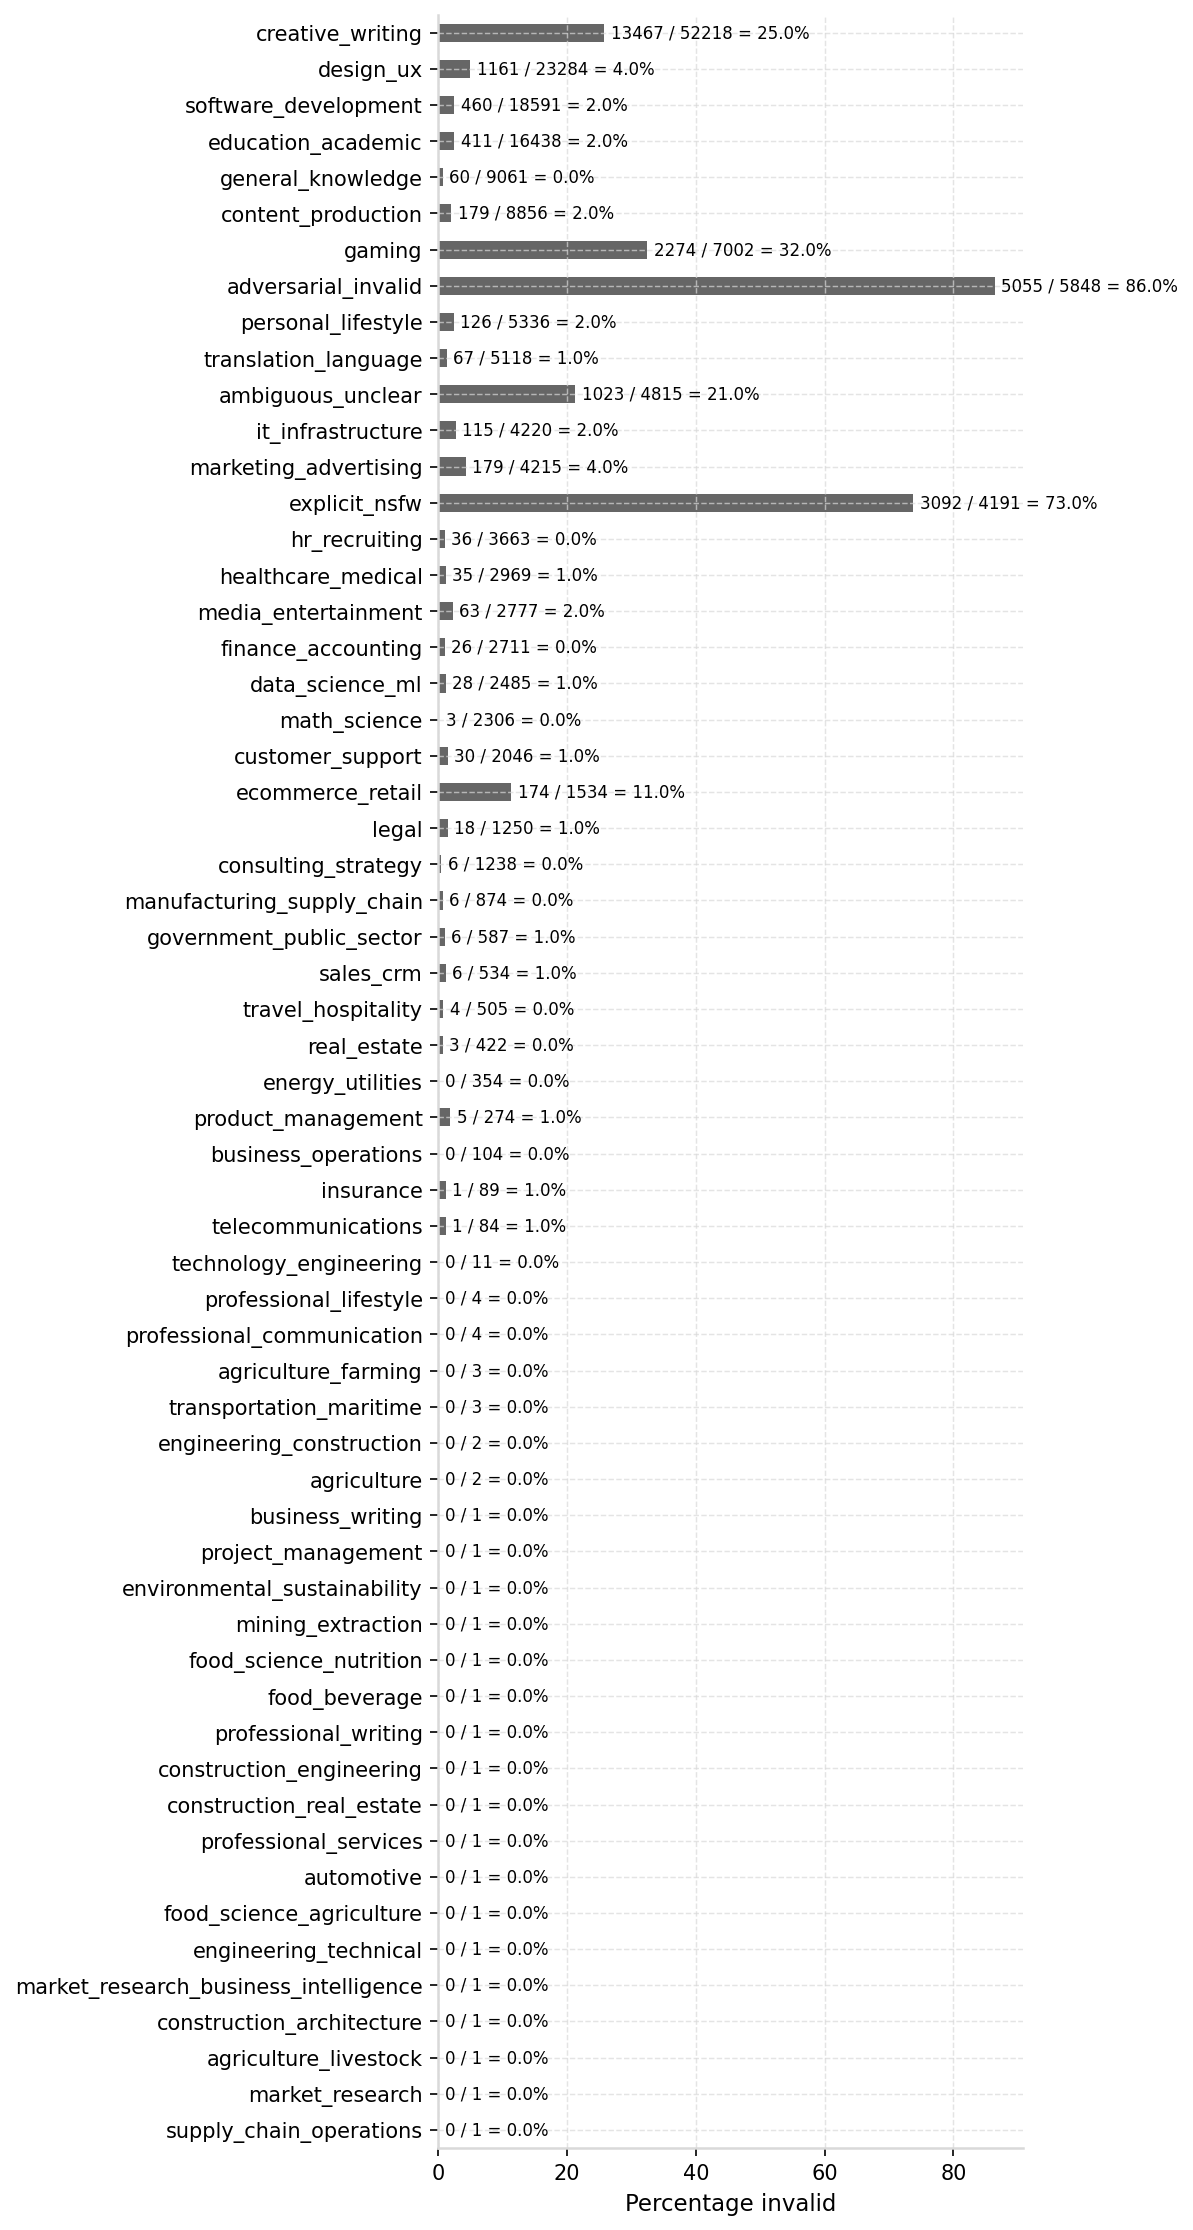

In [84]:
invalid_by_domain_plot(full_df)

In [85]:
invalid_df = full_df[full_df.invalid_input]

In [86]:
quality_dist_plot(invalid_df, "invalid_input_quality.pdf")

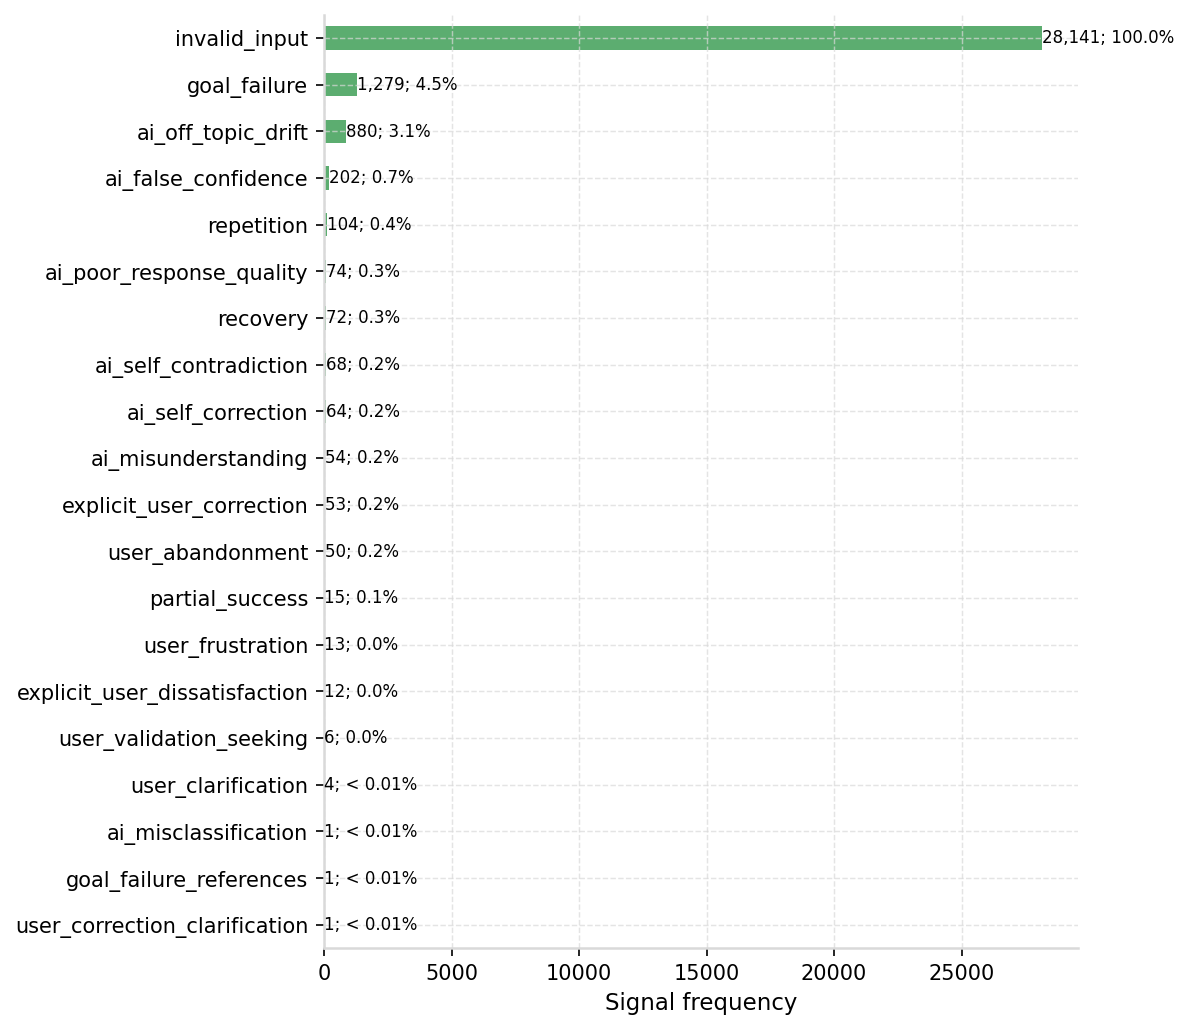

In [87]:
signals_dist_plot(invalid_df, "invalid_input_signals.pdf")

## Archetype distributions from other models

In [88]:
opus_df = pd.read_json(
    os.path.join(DATA_DIRNAME, "wildchat_bigspin_annotations_2k_opus_v1.json.gz"))

opus_df['signals'] = opus_df.signals_json.apply(techreport_utils.get_signals)

opus_df['archetypes'] = opus_df.signals.apply(techreport_utils.assign_archetypes)

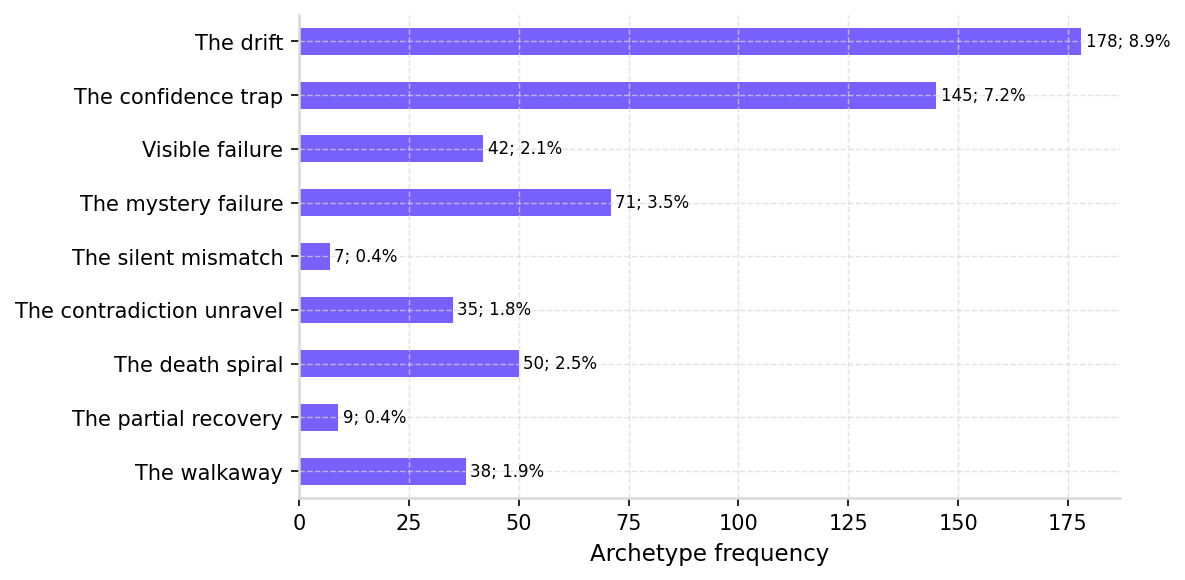

In [89]:
archetype_dist_plot(opus_df, "archetypes_opus.pdf")

In [90]:
gpt_df = pd.read_json(
    os.path.join(DATA_DIRNAME, "wildchat_bigspin_annotations_2k_gpt_v1.json.gz"))

gpt_df['signals'] = gpt_df.signals_json.apply(techreport_utils.get_signals)

gpt_df['archetypes'] = gpt_df.signals.apply(techreport_utils.assign_archetypes)

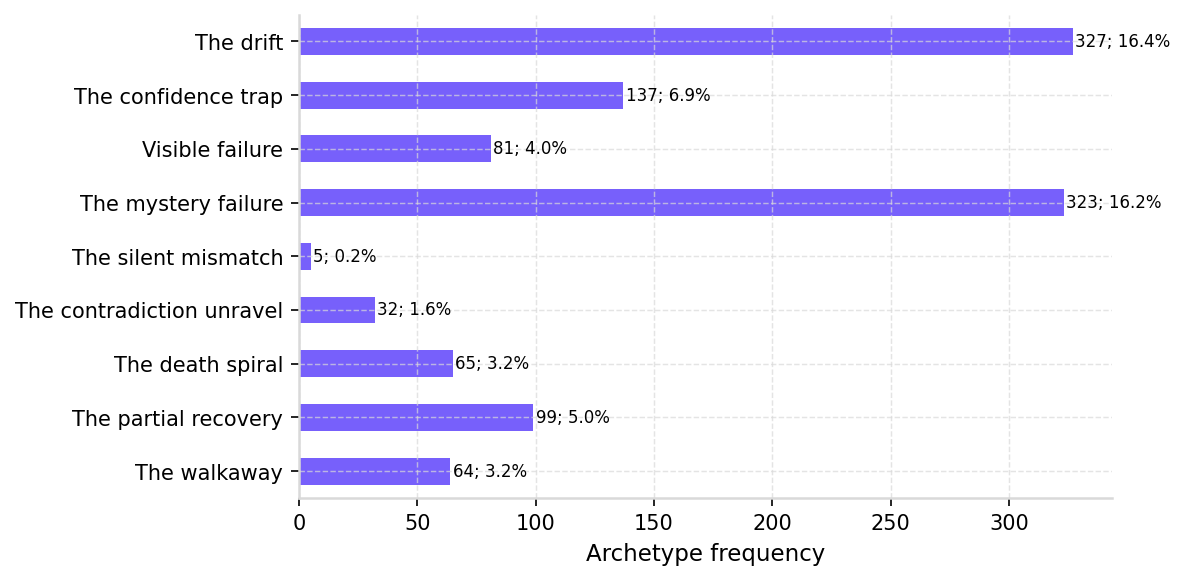

In [91]:
archetype_dist_plot(gpt_df, "archetypes_gpt.pdf")